# 05. Modelos de boosting

Este cuaderno entrena y compara AdaBoost, Gradient Boosting, XGBoost, LightGBM y CatBoost en los problemas de clasificación y regresión. El modelo de boosting basado en histogramas no se incluye, ya que no forma parte del desarrollo teórico del TFG.


#### Índice

1. Librerías utilizadas.
2. Carga y preparación de los datos.
3. Modelos de boosting para clasificación.
4. Modelos de boosting para regresión.
5. Guardado de resultados.


## 1. Librerías utilizadas


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, precision_score, recall_score, r2_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit, ParameterGrid
from xgboost import XGBClassifier, XGBRegressor
from sklearn.utils.class_weight import compute_sample_weight


## 2. Carga y preparación de los datos

Para los modelos distintos de CatBoost, las variables categóricas se codifican mediante `pd.get_dummies`. CatBoost se evalúa de forma diferenciada, ya que permite trabajar directamente con variables categóricas sin aplicar codificación *one-hot*.


In [2]:
bank_train = pd.read_csv("../../data/processed/serie_computacional/bank_train_sin_duration.csv")
bank_test = pd.read_csv("../../data/processed/serie_computacional/bank_test_sin_duration.csv")

power_train = pd.read_csv(
    "../../data/processed/serie_computacional/power_train_hourly.csv",
    parse_dates=["datetime"],
)
power_test = pd.read_csv(
    "../../data/processed/serie_computacional/power_test_hourly.csv",
    parse_dates=["datetime"],
)

objetivo_clasificacion = "y"
objetivo_regresion = "Global_active_energy_kwh"

assert "duration" not in bank_train.columns
assert "duration" not in bank_test.columns
assert objetivo_clasificacion in bank_train.columns
assert objetivo_clasificacion in bank_test.columns
assert objetivo_regresion in power_train.columns
assert objetivo_regresion in power_test.columns

X_train_bank = bank_train.drop(columns=[objetivo_clasificacion]).copy()
y_train_bank = bank_train[objetivo_clasificacion].copy()

X_test_bank = bank_test.drop(columns=[objetivo_clasificacion]).copy()
y_test_bank = bank_test[objetivo_clasificacion].copy()

if y_train_bank.dtype == "object":
    y_train_bank = y_train_bank.map({"no": 0, "yes": 1})
    y_test_bank = y_test_bank.map({"no": 0, "yes": 1})

y_train_bank = y_train_bank.astype(int)
y_test_bank = y_test_bank.astype(int)

variables_numericas_bank = [
    col for col in X_train_bank.columns
    if pd.api.types.is_numeric_dtype(X_train_bank[col])
]

variables_categoricas_bank = [
    col for col in X_train_bank.columns
    if col not in variables_numericas_bank
]

X_train_bank_catboost = X_train_bank.copy()
X_test_bank_catboost = X_test_bank.copy()

for col in variables_numericas_bank:
    mediana = X_train_bank[col].median()

    X_train_bank[col] = X_train_bank[col].fillna(mediana)
    X_test_bank[col] = X_test_bank[col].fillna(mediana)

    X_train_bank_catboost[col] = X_train_bank_catboost[col].fillna(mediana)
    X_test_bank_catboost[col] = X_test_bank_catboost[col].fillna(mediana)

for col in variables_categoricas_bank:
    X_train_bank[col] = X_train_bank[col].fillna("missing")
    X_test_bank[col] = X_test_bank[col].fillna("missing")

    X_train_bank_catboost[col] = X_train_bank_catboost[col].fillna("missing").astype(str)
    X_test_bank_catboost[col] = X_test_bank_catboost[col].fillna("missing").astype(str)

datos_bank = pd.concat([X_train_bank, X_test_bank], axis=0)
datos_bank = pd.get_dummies(datos_bank, columns=variables_categoricas_bank)

X_train_bank_modelo = datos_bank.iloc[:len(X_train_bank)].copy()
X_test_bank_modelo = datos_bank.iloc[len(X_train_bank):].copy()

cat_features_bank = variables_categoricas_bank

X_train_power = power_train.drop(columns=[objetivo_regresion, "datetime"]).copy()
y_train_power = power_train[objetivo_regresion].copy()

X_test_power = power_test.drop(columns=[objetivo_regresion, "datetime"]).copy()
y_test_power = power_test[objetivo_regresion].copy()

variables_numericas_power = list(X_train_power.columns)

for col in variables_numericas_power:
    mediana = X_train_power[col].median()
    X_train_power[col] = X_train_power[col].fillna(mediana)
    X_test_power[col] = X_test_power[col].fillna(mediana)

X_train_power_catboost = X_train_power.copy()
X_test_power_catboost = X_test_power.copy()

cat_features_power = [
    col for col in ["hour", "day_of_week", "month", "is_weekend"]
    if col in X_train_power_catboost.columns
]

for col in cat_features_power:
    X_train_power_catboost[col] = X_train_power_catboost[col].astype(str)
    X_test_power_catboost[col] = X_test_power_catboost[col].astype(str)

resumen_preparacion = pd.DataFrame([
    {
        "bloque": "clasificación",
        "train": len(X_train_bank_modelo),
        "test": len(X_test_bank_modelo),
        "variables": X_train_bank_modelo.shape[1],
        "objetivo": objetivo_clasificacion,
        "catboost_categoricas": len(cat_features_bank),
    },
    {
        "bloque": "regresión",
        "train": len(X_train_power),
        "test": len(X_test_power),
        "variables": X_train_power.shape[1],
        "objetivo": objetivo_regresion,
        "catboost_categoricas": len(cat_features_power),
    },
])

resumen_preparacion

,bloque,train,test,variables,objetivo,catboost_categoricas
0,clasificación,36168,9043,50,y,9
1,regresión,27133,6784,14,Global_active_energy_kwh,4


## 3. Modelos de boosting para clasificación

La búsqueda de hiperparámetros utiliza validación cruzada estratificada. La selección prioriza el F1 de la clase positiva y considera el ROC-AUC como métrica complementaria. El conjunto de prueba se reserva para la evaluación final.


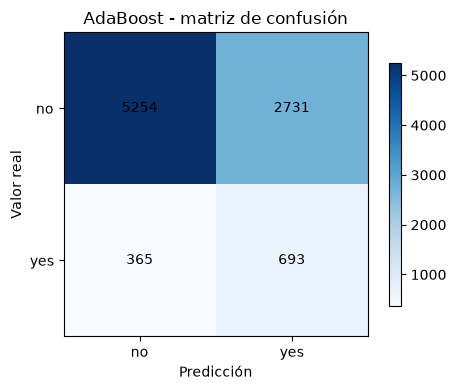

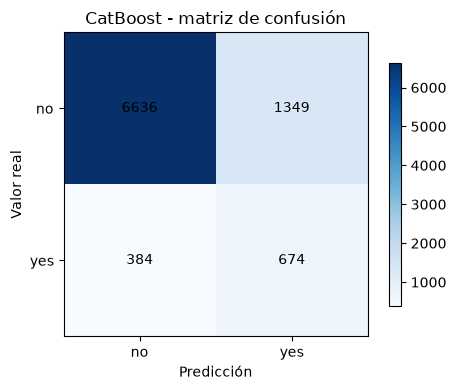

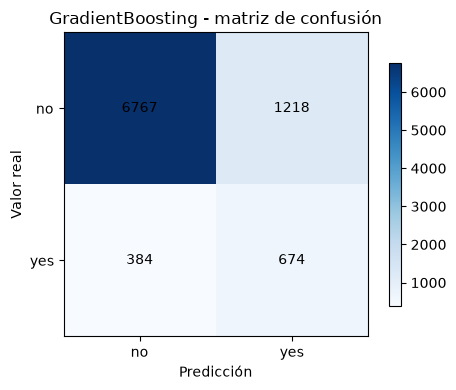

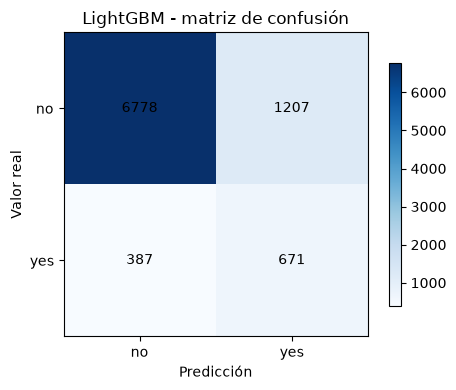

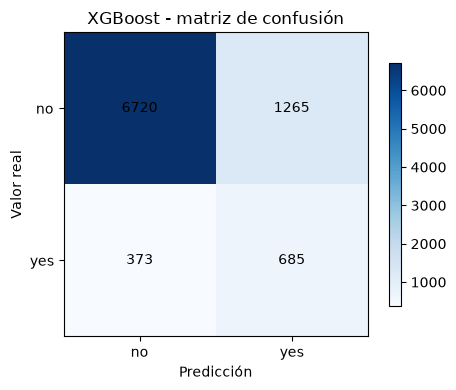

,dataset,escenario,modelo,indice_configuracion,f1_positivo,precision_positiva,recall_positivo,roc_auc,accuracy,n_train,n_test,n_variables_originales,n_variables_numericas,n_variables_categoricas,parametros
0,Bank Marketing,sin_duration,AdaBoost,3,0.309237,0.202395,0.655009,0.715430,0.657636,36168,9043,15,6,9,"{'learning_rate': 0.1, 'n_estimators': 100}"
1,Bank Marketing,sin_duration,CatBoost,65,0.437520,0.333169,0.637051,0.800199,0.808360,36168,9043,15,6,9,"{'learning_rate': 0.1, 'max_depth': 8, 'min_da..."
2,Bank Marketing,sin_duration,GradientBoosting,17,0.456949,0.356237,0.637051,0.803186,0.822846,36168,9043,15,6,9,"{'learning_rate': 0.1, 'max_depth': 8, 'min_sa..."
3,Bank Marketing,sin_duration,LightGBM,48,0.457084,0.357295,0.634216,0.805770,0.823731,36168,9043,15,6,9,"{'learning_rate': 0.1, 'max_depth': 8, 'min_ch..."
4,Bank Marketing,sin_duration,XGBoost,29,0.455452,0.351282,0.647448,0.807038,0.818865,36168,9043,15,6,9,"{'learning_rate': 0.1, 'max_depth': 6, 'min_ch..."


In [3]:
rejilla_adaboost_clasificacion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
}

rejilla_gradient_clasificacion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 8],
    "min_samples_leaf": [50, 100],
}

rejilla_xgboost_clasificacion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 8],
    "min_child_weight": [50, 100],
}

rejilla_lightgbm_clasificacion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 8],
    "min_child_samples": [50, 100],
}

rejilla_catboost_clasificacion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 8],
    "min_data_in_leaf": [50, 100],
}

configuraciones_boosting_clasificacion = []

for parametros in ParameterGrid(rejilla_adaboost_clasificacion):
    configuracion = {"modelo": "AdaBoost"}
    configuracion.update(parametros)
    configuraciones_boosting_clasificacion.append(configuracion)

for parametros in ParameterGrid(rejilla_gradient_clasificacion):
    configuracion = {"modelo": "GradientBoosting"}
    configuracion.update(parametros)
    configuraciones_boosting_clasificacion.append(configuracion)

for nombre_modelo, rejilla in [
    ("XGBoost", rejilla_xgboost_clasificacion),
    ("LightGBM", rejilla_lightgbm_clasificacion),
    ("CatBoost", rejilla_catboost_clasificacion),
]:
    for parametros in ParameterGrid(rejilla):
        configuracion = {"modelo": nombre_modelo}
        configuracion.update(parametros)
        configuraciones_boosting_clasificacion.append(configuracion)

cv_clasificacion = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
filas_busqueda_clasificacion = []

for indice_configuracion, configuracion in enumerate(configuraciones_boosting_clasificacion):
    valores_f1 = []
    valores_roc = []

    if configuracion["modelo"] == "CatBoost":
        X_train_modelo = X_train_bank_catboost
    else:
        X_train_modelo = X_train_bank_modelo

    for indices_train, indices_validacion in cv_clasificacion.split(X_train_modelo, y_train_bank):
        if configuracion["modelo"] == "AdaBoost":
            modelo = AdaBoostClassifier(
                n_estimators=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                random_state=42,
            )

        elif configuracion["modelo"] == "GradientBoosting":
            modelo = GradientBoostingClassifier(
                n_estimators=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                max_depth=configuracion["max_depth"],
                min_samples_leaf=configuracion["min_samples_leaf"],
                random_state=42,
            )

        elif configuracion["modelo"] == "XGBoost":
            modelo = XGBClassifier(
                n_estimators=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                max_depth=configuracion["max_depth"],
                min_child_weight=configuracion["min_child_weight"],
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=42,
                n_jobs=1,
                verbosity=0,
            )

        elif configuracion["modelo"] == "LightGBM":
            modelo = LGBMClassifier(
                n_estimators=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                max_depth=configuracion["max_depth"],
                min_child_samples=configuracion["min_child_samples"],
                random_state=42,
                n_jobs=1,
                verbosity=-1,
            )

        else:
            modelo = CatBoostClassifier(
                iterations=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                depth=configuracion["max_depth"],
                min_data_in_leaf=configuracion["min_data_in_leaf"],
                loss_function="Logloss",
                random_seed=42,
                verbose=False,
                allow_writing_files=False,
            )

        X_entrenamiento = X_train_modelo.iloc[indices_train]
        y_entrenamiento = y_train_bank.iloc[indices_train]
        X_validacion = X_train_modelo.iloc[indices_validacion]
        y_validacion = y_train_bank.iloc[indices_validacion]

        pesos_entrenamiento = compute_sample_weight(
            class_weight="balanced",
            y=y_entrenamiento,
        )

        if configuracion["modelo"] == "CatBoost":
            modelo.fit(
                X_entrenamiento,
                y_entrenamiento,
                cat_features=cat_features_bank,
                sample_weight=pesos_entrenamiento,
                verbose=False,
            )
        else:
            modelo.fit(
                X_entrenamiento,
                y_entrenamiento,
                sample_weight=pesos_entrenamiento,
            )

        predicciones_validacion = modelo.predict(X_validacion)
        probabilidades_validacion = modelo.predict_proba(X_validacion)[:, 1]

        valores_f1.append(
            f1_score(
                y_validacion,
                predicciones_validacion,
                pos_label=1,
                zero_division=0,
            )
        )

        valores_roc.append(
            roc_auc_score(
                y_validacion,
                probabilidades_validacion,
            )
        )

    filas_busqueda_clasificacion.append({
        "indice_configuracion": indice_configuracion,
        "modelo": configuracion["modelo"],
        "parametros": str({k: v for k, v in configuracion.items() if k != "modelo"}),
        "f1_positivo_cv_media": np.mean(valores_f1),
        "f1_positivo_cv_std": np.std(valores_f1),
        "roc_auc_cv_media": np.mean(valores_roc),
        "roc_auc_cv_std": np.std(valores_roc),
    })

busqueda_boosting_clasificacion = pd.DataFrame(filas_busqueda_clasificacion)

mejores_boosting_clasificacion = (
    busqueda_boosting_clasificacion
    .sort_values(
        ["modelo", "f1_positivo_cv_media", "roc_auc_cv_media"],
        ascending=[True, False, False],
    )
    .groupby("modelo", as_index=False)
    .head(1)
)

filas_clasificacion = []
filas_matrices = []
matrices_para_grafico = {}

for _, fila_mejor in mejores_boosting_clasificacion.iterrows():
    configuracion = configuraciones_boosting_clasificacion[int(fila_mejor["indice_configuracion"])]

    if configuracion["modelo"] == "CatBoost":
        X_train_modelo = X_train_bank_catboost
        X_test_modelo = X_test_bank_catboost
    else:
        X_train_modelo = X_train_bank_modelo
        X_test_modelo = X_test_bank_modelo

    if configuracion["modelo"] == "AdaBoost":
        modelo = AdaBoostClassifier(
            n_estimators=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            random_state=42,
        )

    elif configuracion["modelo"] == "GradientBoosting":
        modelo = GradientBoostingClassifier(
            n_estimators=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            max_depth=configuracion["max_depth"],
            min_samples_leaf=configuracion["min_samples_leaf"],
            random_state=42,
        )

    elif configuracion["modelo"] == "XGBoost":
        modelo = XGBClassifier(
            n_estimators=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            max_depth=configuracion["max_depth"],
            min_child_weight=configuracion["min_child_weight"],
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=1,
            verbosity=0,
        )

    elif configuracion["modelo"] == "LightGBM":
        modelo = LGBMClassifier(
            n_estimators=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            max_depth=configuracion["max_depth"],
            min_child_samples=configuracion["min_child_samples"],
            random_state=42,
            n_jobs=1,
            verbosity=-1,
        )

    else:
        modelo = CatBoostClassifier(
            iterations=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            depth=configuracion["max_depth"],
            min_data_in_leaf=configuracion["min_data_in_leaf"],
            loss_function="Logloss",
            random_seed=42,
            verbose=False,
            allow_writing_files=False,
        )

    pesos_entrenamiento = compute_sample_weight(
        class_weight="balanced",
        y=y_train_bank,
    )

    if configuracion["modelo"] == "CatBoost":
        modelo.fit(
            X_train_modelo,
            y_train_bank,
            cat_features=cat_features_bank,
            sample_weight=pesos_entrenamiento,
            verbose=False,
        )
    else:
        modelo.fit(
            X_train_modelo,
            y_train_bank,
            sample_weight=pesos_entrenamiento,
        )

    predicciones = modelo.predict(X_test_modelo)
    probabilidades = modelo.predict_proba(X_test_modelo)[:, 1]

    matriz = confusion_matrix(
        y_test_bank,
        predicciones,
        labels=[0, 1],
    )

    tn, fp, fn, tp = matriz.ravel()
    matrices_para_grafico[configuracion["modelo"]] = matriz

    filas_clasificacion.append({
        "dataset": "Bank Marketing",
        "escenario": "sin_duration",
        "modelo": configuracion["modelo"],
        "indice_configuracion": int(fila_mejor["indice_configuracion"]),
        "f1_positivo": f1_score(y_test_bank, predicciones, pos_label=1, zero_division=0),
        "precision_positiva": precision_score(y_test_bank, predicciones, pos_label=1, zero_division=0),
        "recall_positivo": recall_score(y_test_bank, predicciones, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_test_bank, probabilidades),
        "accuracy": accuracy_score(y_test_bank, predicciones),
        "n_train": len(X_train_modelo),
        "n_test": len(X_test_modelo),
        "n_variables_originales": X_train_bank.shape[1],
        "n_variables_numericas": len(variables_numericas_bank),
        "n_variables_categoricas": len(variables_categoricas_bank),
        "parametros": str({k: v for k, v in configuracion.items() if k != "modelo"}),
    })

    filas_matrices.append({
        "dataset": "Bank Marketing",
        "escenario": "sin_duration",
        "modelo": configuracion["modelo"],
        "indice_configuracion": int(fila_mejor["indice_configuracion"]),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    })

resultados_boosting_clasificacion = pd.DataFrame(filas_clasificacion)
matrices_boosting_clasificacion = pd.DataFrame(filas_matrices)

for nombre_modelo, matriz in matrices_para_grafico.items():
    fig, ax = plt.subplots(figsize=(5, 4))

    imagen = ax.imshow(matriz, cmap="Blues")

    ax.set_title(f"{nombre_modelo} - matriz de confusión")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticks([0, 1], labels=["no", "yes"])
    ax.set_yticks([0, 1], labels=["no", "yes"])

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(
                j,
                i,
                matriz[i, j],
                ha="center",
                va="center",
                color="black",
            )

    fig.colorbar(imagen, ax=ax, shrink=0.8)
    fig.tight_layout()
    plt.show()

resultados_boosting_clasificacion

## 4. Modelos de boosting para regresión

El problema de regresión se evalúa mediante validación temporal, con el RMSE como métrica principal y el R² como medida complementaria. CatBoost trata como categóricas determinadas variables de calendario, como la hora o el día de la semana, porque representan categorías temporales discretas.


In [4]:
rejilla_adaboost_regresion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
}

rejilla_gradient_regresion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 8],
    "min_samples_leaf": [50, 100],
}

rejilla_xgboost_regresion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 8],
    "min_child_weight": [50, 100],
}

rejilla_lightgbm_regresion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 8],
    "min_child_samples": [50, 100],
}

rejilla_catboost_regresion = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 8],
    "min_data_in_leaf": [50, 100],
}

configuraciones_boosting_regresion = []

for parametros in ParameterGrid(rejilla_adaboost_regresion):
    configuracion = {"modelo": "AdaBoost"}
    configuracion.update(parametros)
    configuraciones_boosting_regresion.append(configuracion)

for parametros in ParameterGrid(rejilla_gradient_regresion):
    configuracion = {"modelo": "GradientBoosting"}
    configuracion.update(parametros)
    configuraciones_boosting_regresion.append(configuracion)

for nombre_modelo, rejilla in [
    ("XGBoost", rejilla_xgboost_regresion),
    ("LightGBM", rejilla_lightgbm_regresion),
    ("CatBoost", rejilla_catboost_regresion),
]:
    for parametros in ParameterGrid(rejilla):
        configuracion = {"modelo": nombre_modelo}
        configuracion.update(parametros)
        configuraciones_boosting_regresion.append(configuracion)

cv_temporal = TimeSeriesSplit(n_splits=3)
filas_busqueda_regresion = []

for indice_configuracion, configuracion in enumerate(configuraciones_boosting_regresion):
    valores_rmse = []
    valores_r2 = []

    if configuracion["modelo"] == "CatBoost":
        X_train_modelo = X_train_power_catboost
    else:
        X_train_modelo = X_train_power

    for indices_train, indices_validacion in cv_temporal.split(X_train_modelo):
        if configuracion["modelo"] == "AdaBoost":
            modelo = AdaBoostRegressor(
                n_estimators=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                random_state=42,
            )

        elif configuracion["modelo"] == "GradientBoosting":
            modelo = GradientBoostingRegressor(
                n_estimators=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                max_depth=configuracion["max_depth"],
                min_samples_leaf=configuracion["min_samples_leaf"],
                random_state=42,
            )

        elif configuracion["modelo"] == "XGBoost":
            modelo = XGBRegressor(
                n_estimators=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                max_depth=configuracion["max_depth"],
                min_child_weight=configuracion["min_child_weight"],
                objective="reg:squarederror",
                eval_metric="rmse",
                tree_method="hist",
                random_state=42,
                n_jobs=1,
                verbosity=0,
            )

        elif configuracion["modelo"] == "LightGBM":
            modelo = LGBMRegressor(
                n_estimators=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                max_depth=configuracion["max_depth"],
                min_child_samples=configuracion["min_child_samples"],
                random_state=42,
                n_jobs=1,
                verbosity=-1,
            )

        else:
            modelo = CatBoostRegressor(
                iterations=configuracion["n_estimators"],
                learning_rate=configuracion["learning_rate"],
                depth=configuracion["max_depth"],
                min_data_in_leaf=configuracion["min_data_in_leaf"],
                loss_function="RMSE",
                random_seed=42,
                verbose=False,
                allow_writing_files=False,
            )

        X_entrenamiento = X_train_modelo.iloc[indices_train]
        y_entrenamiento = y_train_power.iloc[indices_train]
        X_validacion = X_train_modelo.iloc[indices_validacion]
        y_validacion = y_train_power.iloc[indices_validacion]

        if configuracion["modelo"] == "CatBoost":
            modelo.fit(
                X_entrenamiento,
                y_entrenamiento,
                cat_features=cat_features_power,
                verbose=False,
            )
        else:
            modelo.fit(
                X_entrenamiento,
                y_entrenamiento,
            )

        predicciones_validacion = modelo.predict(X_validacion)

        mse_validacion = mean_squared_error(
            y_validacion,
            predicciones_validacion,
        )

        valores_rmse.append(np.sqrt(mse_validacion))

        valores_r2.append(
            r2_score(
                y_validacion,
                predicciones_validacion,
            )
        )

    filas_busqueda_regresion.append({
        "indice_configuracion": indice_configuracion,
        "modelo": configuracion["modelo"],
        "parametros": str({k: v for k, v in configuracion.items() if k != "modelo"}),
        "rmse_cv_media": np.mean(valores_rmse),
        "rmse_cv_std": np.std(valores_rmse),
        "r2_cv_media": np.mean(valores_r2),
        "r2_cv_std": np.std(valores_r2),
    })

busqueda_boosting_regresion = pd.DataFrame(filas_busqueda_regresion)

mejores_boosting_regresion = (
    busqueda_boosting_regresion
    .sort_values(
        ["modelo", "rmse_cv_media", "r2_cv_media"],
        ascending=[True, True, False],
    )
    .groupby("modelo", as_index=False)
    .head(1)
)

filas_regresion = []

for _, fila_mejor in mejores_boosting_regresion.iterrows():
    configuracion = configuraciones_boosting_regresion[int(fila_mejor["indice_configuracion"])]

    if configuracion["modelo"] == "CatBoost":
        X_final_train = X_train_power_catboost
        X_final_test = X_test_power_catboost
    else:
        X_final_train = X_train_power
        X_final_test = X_test_power

    if configuracion["modelo"] == "AdaBoost":
        modelo = AdaBoostRegressor(
            n_estimators=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            random_state=42,
        )

    elif configuracion["modelo"] == "GradientBoosting":
        modelo = GradientBoostingRegressor(
            n_estimators=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            max_depth=configuracion["max_depth"],
            min_samples_leaf=configuracion["min_samples_leaf"],
            random_state=42,
        )

    elif configuracion["modelo"] == "XGBoost":
        modelo = XGBRegressor(
            n_estimators=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            max_depth=configuracion["max_depth"],
            min_child_weight=configuracion["min_child_weight"],
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            random_state=42,
            n_jobs=1,
            verbosity=0,
        )

    elif configuracion["modelo"] == "LightGBM":
        modelo = LGBMRegressor(
            n_estimators=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            max_depth=configuracion["max_depth"],
            min_child_samples=configuracion["min_child_samples"],
            random_state=42,
            n_jobs=1,
            verbosity=-1,
        )

    else:
        modelo = CatBoostRegressor(
            iterations=configuracion["n_estimators"],
            learning_rate=configuracion["learning_rate"],
            depth=configuracion["max_depth"],
            min_data_in_leaf=configuracion["min_data_in_leaf"],
            loss_function="RMSE",
            random_seed=42,
            verbose=False,
            allow_writing_files=False,
        )

    if configuracion["modelo"] == "CatBoost":
        modelo.fit(
            X_final_train,
            y_train_power,
            cat_features=cat_features_power,
            verbose=False,
        )
    else:
        modelo.fit(
            X_final_train,
            y_train_power,
        )

    predicciones = modelo.predict(X_final_test)

    mse = mean_squared_error(
        y_test_power,
        predicciones,
    )

    filas_regresion.append({
        "dataset": "Individual Household Electric Power Consumption",
        "modelo": configuracion["modelo"],
        "indice_configuracion": int(fila_mejor["indice_configuracion"]),
        "rmse": np.sqrt(mse),
        "mae": mean_absolute_error(y_test_power, predicciones),
        "mse": mse,
        "r2": r2_score(y_test_power, predicciones),
        "n_train": len(X_final_train),
        "n_test": len(X_final_test),
        "n_variables_originales": X_train_power.shape[1],
        "n_variables_numericas": len(variables_numericas_power),
        "n_variables_categoricas": len(cat_features_power) if configuracion["modelo"] == "CatBoost" else 0,
        "parametros": str({k: v for k, v in configuracion.items() if k != "modelo"}),
        "preprocesamiento": "categóricas nativas" if configuracion["modelo"] == "CatBoost" else "variables numéricas",
    })

resultados_boosting_regresion = pd.DataFrame(filas_regresion)

resultados_boosting_regresion

,dataset,modelo,indice_configuracion,rmse,mae,mse,r2,n_train,n_test,n_variables_originales,n_variables_numericas,n_variables_categoricas,parametros,preprocesamiento
0,Individual Household Electric Power Consumption,AdaBoost,0,0.532167,0.384656,0.283201,0.487349,27133,6784,14,14,0,"{'learning_rate': 0.05, 'n_estimators': 50}",variables numéricas
1,Individual Household Electric Power Consumption,CatBoost,65,0.484118,0.337725,0.234370,0.575743,27133,6784,14,14,4,"{'learning_rate': 0.1, 'max_depth': 8, 'min_da...",categóricas nativas
2,Individual Household Electric Power Consumption,GradientBoosting,5,0.476158,0.331021,0.226727,0.589579,27133,6784,14,14,0,"{'learning_rate': 0.05, 'max_depth': 6, 'min_s...",variables numéricas
3,Individual Household Electric Power Consumption,LightGBM,41,0.474344,0.328266,0.225002,0.592701,27133,6784,14,14,0,"{'learning_rate': 0.05, 'max_depth': 8, 'min_c...",variables numéricas
4,Individual Household Electric Power Consumption,XGBoost,21,0.475012,0.330122,0.225637,0.591553,27133,6784,14,14,0,"{'learning_rate': 0.05, 'max_depth': 6, 'min_c...",variables numéricas


## 5. Guardado de resultados

En este bloque se guardan las métricas de evaluación, los resultados de validación y las matrices de confusión de los modelos de boosting.


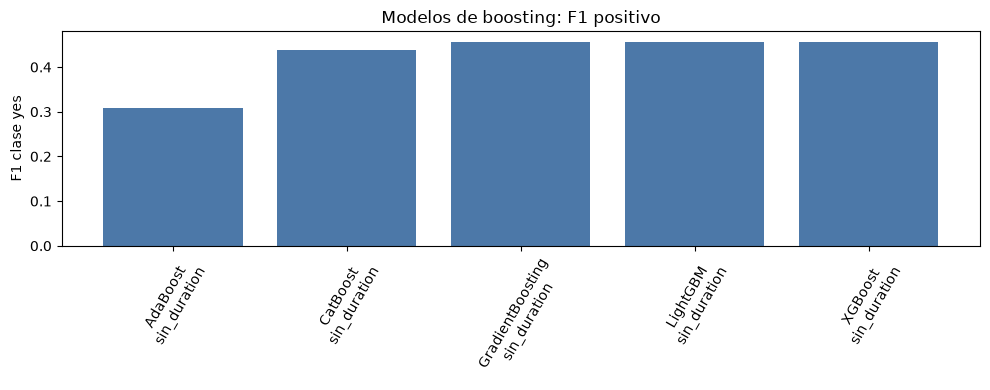

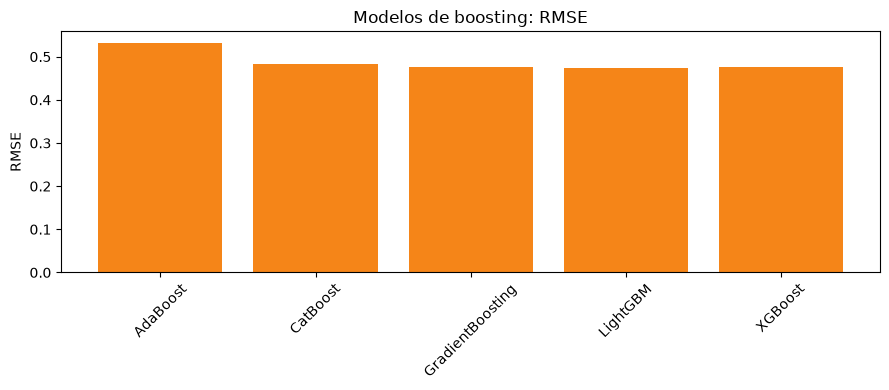

In [5]:
ruta_tablas = "../../reports/tables/serie_computacional"
ruta_figuras = "../../reports/figures/serie_computacional"

os.makedirs(ruta_tablas, exist_ok=True)
os.makedirs(ruta_figuras, exist_ok=True)

resultados_boosting_clasificacion.to_csv(f"{ruta_tablas}/boosting_clasificacion_metricas.csv", index=False)
resultados_boosting_regresion.to_csv(f"{ruta_tablas}/boosting_regresion_metricas.csv", index=False)

busqueda_boosting_clasificacion.to_csv(f"{ruta_tablas}/boosting_busqueda_hiperparametros_clasificacion.csv", index=False)
busqueda_boosting_regresion.to_csv(f"{ruta_tablas}/boosting_busqueda_hiperparametros_regresion.csv", index=False)

busqueda_boosting_clasificacion.to_csv(f"{ruta_tablas}/boosting_validacion_cruzada_clasificacion.csv", index=False)
busqueda_boosting_regresion.to_csv(f"{ruta_tablas}/boosting_validacion_temporal_regresion.csv", index=False)

matrices_boosting_clasificacion.to_csv(f"{ruta_tablas}/boosting_matrices_confusion.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))

grafico = resultados_boosting_clasificacion.copy()
grafico["etiqueta"] = grafico["modelo"] + "\n" + grafico["escenario"]

ax.bar(grafico["etiqueta"], grafico["f1_positivo"], color="#4c78a8")
ax.set_title("Modelos de boosting: F1 positivo")
ax.set_ylabel("F1 clase yes")
ax.tick_params(axis="x", rotation=60)

fig.tight_layout()
fig.savefig(f"{ruta_figuras}/boosting_clasificacion_f1.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(resultados_boosting_regresion["modelo"], resultados_boosting_regresion["rmse"], color="#f58518")
ax.set_title("Modelos de boosting: RMSE")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(f"{ruta_figuras}/boosting_regresion_rmse.png", dpi=150, bbox_inches="tight")
plt.show()